# Exemplo 05 - Problema da Mochila com a Biblioteca PyGAD

---

## Objetivo

Nos exemplos anteriores (01-04), implementamos **cada componente** do AG na mao:
- Exemplo 01: Selecao por Roleta
- Exemplo 02: AG completo (Mochila)
- Exemplo 03: Crossover
- Exemplo 04: Mutacao

Agora vamos resolver o **mesmo problema da mochila** usando a biblioteca **PyGAD**, que ja tem tudo pronto!

## Por que usar uma biblioteca?

| Na mao (Exemplo 02) | Com PyGAD (este exemplo) |
|:---:|:---:|
| ~120 linhas de codigo | ~20 linhas de codigo |
| Bom para aprender | Bom para produtividade |
| Controle total | Parametrizacao simples |

**MAS**: so conseguimos usar a PyGAD de forma consciente porque **entendemos** o que cada parametro significa!

In [1]:
# Instalar a PyGAD (rodar apenas uma vez)
%pip install pygad -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pygad

---
## Passo 1: Definir o problema (mesmo do Exemplo 02)

In [3]:
# Itens disponiveis: cada item tem nome, peso (kg) e valor (R$)
itens = [
    {"nome": "Notebook",      "peso": 3.0, "valor": 2000},
    {"nome": "Livro de IA",   "peso": 1.5, "valor": 300},
    {"nome": "Garrafa agua",  "peso": 1.0, "valor": 50},
    {"nome": "Camera",        "peso": 2.0, "valor": 1500},
    {"nome": "Casaco",        "peso": 1.5, "valor": 200},
    {"nome": "Lanche",        "peso": 0.5, "valor": 80},
    {"nome": "Carregador",    "peso": 0.5, "valor": 150},
    {"nome": "Tablet",        "peso": 1.0, "valor": 1200},
]

PESO_MAXIMO = 7.0
NUM_ITENS = len(itens)

print("Itens disponiveis:")
for item in itens:
    print(" ", item["nome"], "\t", item["peso"], "kg \tR$", item["valor"])
print()
print("Peso maximo:", PESO_MAXIMO, "kg")

Itens disponiveis:
  Notebook 	 3.0 kg 	R$ 2000
  Livro de IA 	 1.5 kg 	R$ 300
  Garrafa agua 	 1.0 kg 	R$ 50
  Camera 	 2.0 kg 	R$ 1500
  Casaco 	 1.5 kg 	R$ 200
  Lanche 	 0.5 kg 	R$ 80
  Carregador 	 0.5 kg 	R$ 150
  Tablet 	 1.0 kg 	R$ 1200

Peso maximo: 7.0 kg


---
## Passo 2: Definir a funcao de fitness

Esta e a **UNICA parte** que precisamos programar!  
Todo o resto (selecao, crossover, mutacao) a PyGAD faz sozinha.

A PyGAD exige que a funcao tenha 3 parametros:
- `ga_instance`: a instancia do AG (obrigatorio)
- `solution`: o cromossomo do individuo
- `solution_idx`: indice da solucao

In [4]:
def funcao_fitness(ga_instance, solution, solution_idx):
    """
    Avalia uma solucao para o problema da mochila.
    Mesma logica do Exemplo 02!
    """
    peso_total = 0
    valor_total = 0

    for i in range(NUM_ITENS):
        if solution[i] == 1:
            peso_total += itens[i]["peso"]
            valor_total += itens[i]["valor"]

    # Penalizacao: se excedeu o peso, fitness = 0
    if peso_total > PESO_MAXIMO:
        return 0

    return valor_total

print("Funcao de fitness definida!")

Funcao de fitness definida!


---
## Passo 3: Configurar o AG

Aqui e onde a **magica** acontece! Veja como cada parametro mapeia para os conceitos que aprendemos:

| Parametro PyGAD | Conceito | Exemplo onde aprendemos |
|:---|:---|:---:|
| `parent_selection_type="rws"` | Selecao por Roleta | Exemplo 01 |
| `crossover_type="single_point"` | Crossover de 1 ponto | Exemplo 03 |
| `mutation_type="random"` | Mutacao aleatoria | Exemplo 04 |
| `keep_elitism=1` | Elitismo | Exemplo 02 |
| `gene_space=[0, 1]` | Cromossomo binario | Exemplo 02 |

In [5]:
# Callback para acompanhar a evolucao
def callback_geracao(ga_instance):
    geracao = ga_instance.generations_completed
    melhor = ga_instance.best_solution()[1]
    if geracao % 10 == 0 or geracao == 1:
        print("  Geracao", geracao, " |  Melhor fitness: R$", round(melhor))

# Configurar o AG com PyGAD
ag = pygad.GA(
    # --- Parametros basicos ---
    num_generations=50,            # Numero de geracoes
    num_parents_mating=10,         # Pais selecionados para cruzamento
    sol_per_pop=20,                # Tamanho da populacao

    # --- Cromossomo ---
    num_genes=NUM_ITENS,           # Genes = numero de itens
    gene_type=int,                 # Genes inteiros (0 ou 1)
    gene_space=[0, 1],             # Valores possiveis: binario

    # --- Fitness ---
    fitness_func=funcao_fitness,

    # --- Selecao (Exemplo 01!) ---
    parent_selection_type="rws",   # rws = Roulette Wheel Selection

    # --- Crossover (Exemplo 03!) ---
    crossover_type="single_point", # Crossover de um ponto
    crossover_probability=0.8,     # 80% de chance

    # --- Mutacao (Exemplo 04!) ---
    mutation_type="random",        # Mutacao aleatoria
    mutation_probability=0.05,     # 5% por gene

    # --- Elitismo (Exemplo 02!) ---
    keep_elitism=1,

    # --- Callback ---
    on_generation=callback_geracao,
    suppress_warnings=True,
)

print("AG configurado! Pronto para rodar.")

AG configurado! Pronto para rodar.


---
## Passo 4: Rodar o AG!

In [6]:
# Rodar!
ag.run()

  Geracao 1  |  Melhor fitness: R$ 3880
  Geracao 10  |  Melhor fitness: R$ 4780
  Geracao 20  |  Melhor fitness: R$ 4930
  Geracao 30  |  Melhor fitness: R$ 4930
  Geracao 40  |  Melhor fitness: R$ 4930
  Geracao 50  |  Melhor fitness: R$ 4930


---
## Passo 5: Ver os resultados

In [7]:
# Obter a melhor solucao
solucao, fitness, idx = ag.best_solution()

print("MELHOR SOLUCAO ENCONTRADA")
print("=" * 50)

peso_total = 0
valor_total = 0

for i in range(NUM_ITENS):
    if solucao[i] == 1:
        print("  [X]", itens[i]["nome"], "-", itens[i]["peso"], "kg - R$", itens[i]["valor"])
        peso_total += itens[i]["peso"]
        valor_total += itens[i]["valor"]
    else:
        print("  [ ]", itens[i]["nome"])

print()
print("  Cromossomo:", [int(g) for g in solucao])
print("  Peso total:", peso_total, "kg (limite:", PESO_MAXIMO, "kg)")
print("  Valor total: R$", valor_total)

MELHOR SOLUCAO ENCONTRADA
  [ ] Notebook
  [X] Livro de IA - 1.5 kg - R$ 300
  [ ] Garrafa agua
  [X] Camera - 2.0 kg - R$ 1500
  [X] Casaco - 1.5 kg - R$ 200
  [X] Lanche - 0.5 kg - R$ 80
  [X] Carregador - 0.5 kg - R$ 150
  [X] Tablet - 1.0 kg - R$ 1200

  Cromossomo: [0, 1, 0, 1, 1, 1, 1, 1]
  Peso total: 7.0 kg (limite: 7.0 kg)
  Valor total: R$ 3430


---
## Passo 6: Grafico da evolucao

A PyGAD gera graficos automaticamente! Vamos ver como o fitness evoluiu:

C:\Users\Aluno\AppData\Roaming\Python\Python314\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


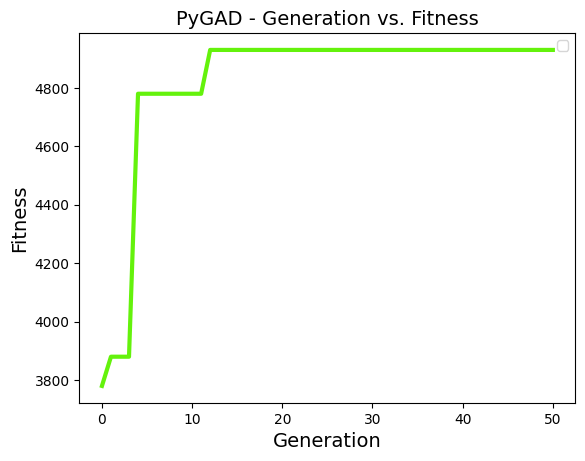

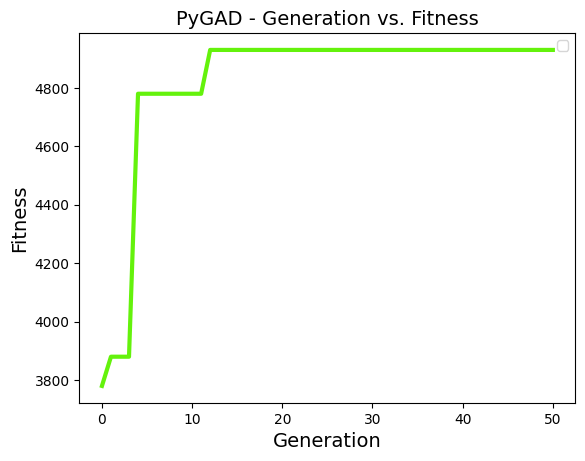

In [8]:
# Grafico da evolucao do fitness ao longo das geracoes
ag.plot_fitness()

---
## Comparacao: Na mao vs PyGAD

| Aspecto | Na mao (Exemplo 02) | Com PyGAD |
|:---|:---:|:---:|
| Linhas de codigo | ~120 | ~20 |
| Funcoes implementadas | 7 | 1 (so o fitness) |
| Graficos | Nao | Sim (automatico!) |
| Flexibilidade | Total | Limitada aos metodos da lib |
| Aprendizado | Alto | Baixo (caixa preta) |

### Conclusao para a aula:

> **Primeiro aprenda os fundamentos (exemplos 01-04), depois use bibliotecas (exemplo 05).**  
> Usar uma biblioteca sem entender os conceitos e como dirigir um carro sem saber como funciona o motor -- funciona ate dar problema!

### Exercicio:

Mude o `parent_selection_type` de `"rws"` (roleta) para `"tournament"` (torneio) e compare os resultados!